In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib



In [5]:
# Load the CSV file
df = pd.read_csv("/Users/abhishekdas/Documents/ML_FastAPI/Data/insurance.csv")

# Data inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample rows:")
display(df.head())

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses']

Sample rows:


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


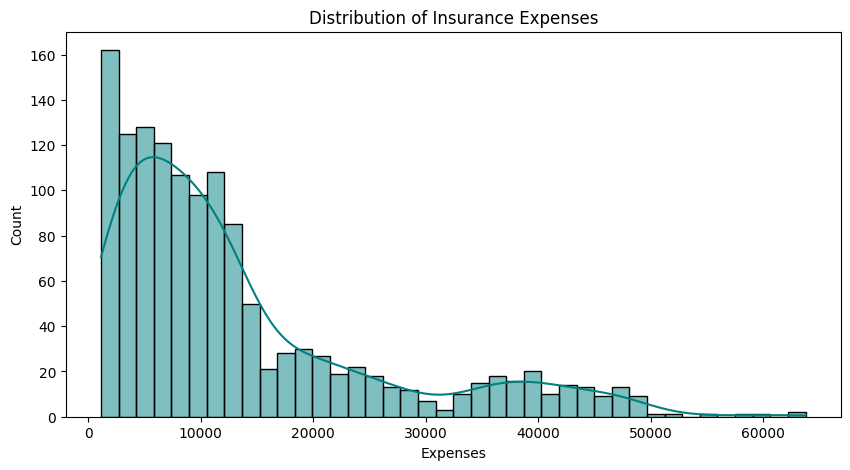

In [11]:
## Distribution of Insurance Expense

plt.figure(figsize=(10,5))
sns.histplot(df['expenses'], bins=40, kde=True, color='teal')
plt.title("Distribution of Insurance Expenses")
plt.xlabel("Expenses")
plt.ylabel("Count")
plt.show()


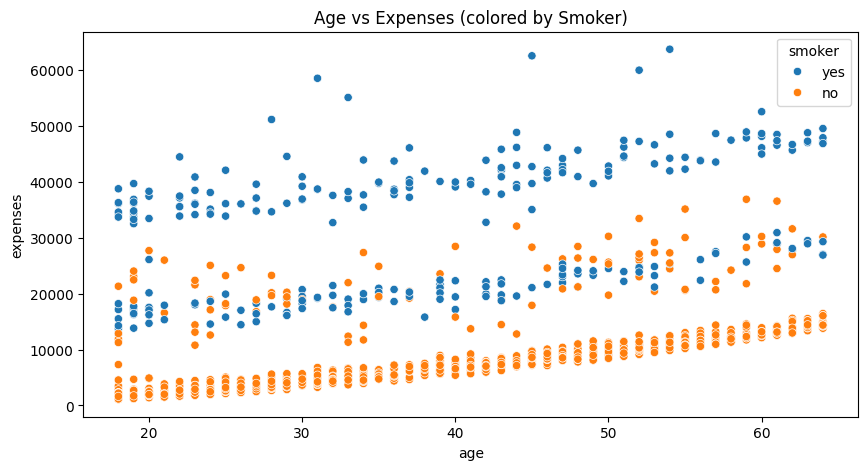

In [12]:
## Age VS Expense
plt.figure(figsize=(10,5))
sns.scatterplot(x='age', y='expenses', data=df, hue='smoker', alpha=1)
plt.title("Age vs Expenses (colored by Smoker)")
plt.show()


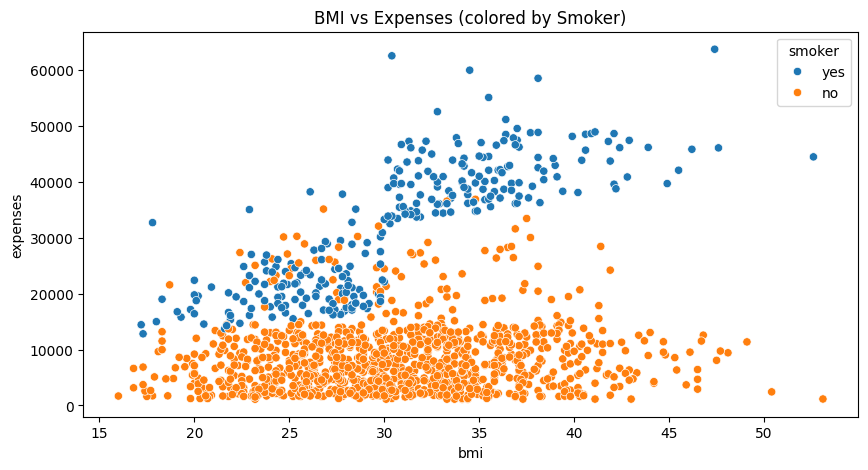

In [15]:
## BMI vs Expense
plt.figure(figsize=(10,5))
sns.scatterplot(x='bmi', y='expenses', data=df, hue='smoker', alpha=1)
plt.title("BMI vs Expenses (colored by Smoker)")
plt.show()


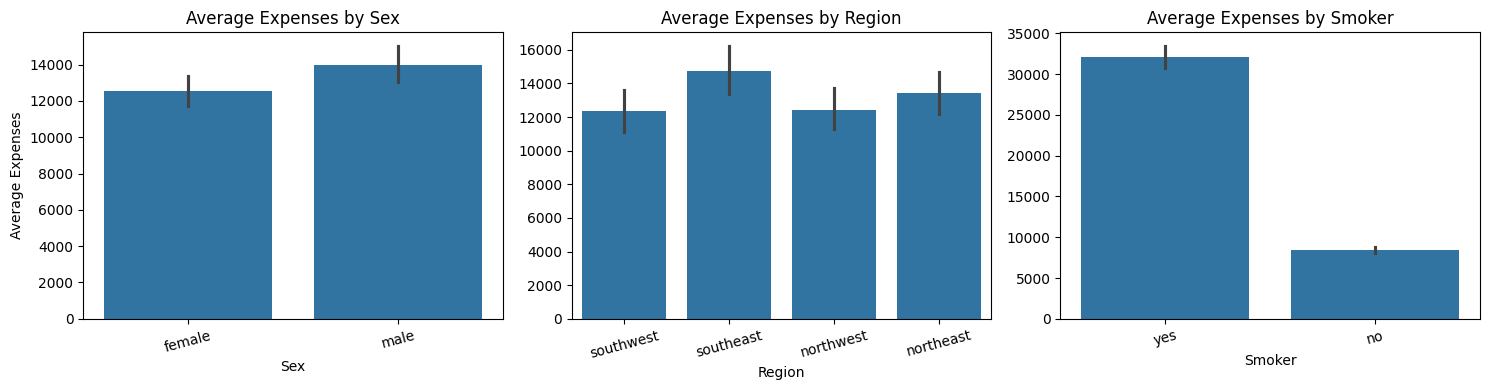

In [18]:
## Categorical Features VS Expense
categorical_cols = ['sex', 'region', 'smoker']

plt.figure(figsize=(15, 4))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 3, i)
    sns.barplot(x=col, y='expenses', data=df, estimator='mean')
    plt.title(f"Average Expenses by {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Average Expenses" if i == 1 else "")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


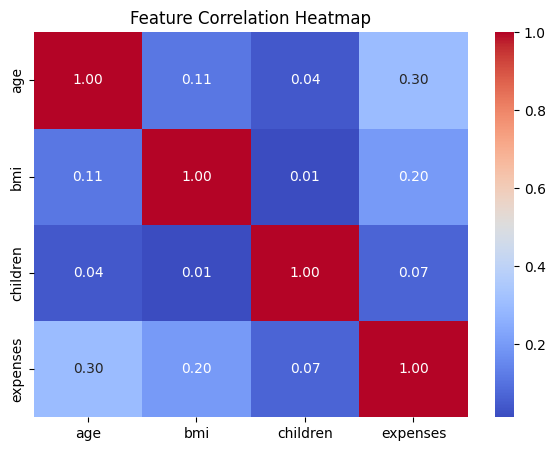

In [19]:
## Correaltion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [25]:
## Data Preprocessing and Feature Engineering
## Define target and features
X = df.drop(columns=["expenses"])
y = df["expenses"]

# Define column types for one hot encoding and label encoding
numeric = ["age", "bmi", "children"]
categorical = ["sex", "smoker", "region"]

# scaler and OHE preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(drop="first"), categorical)
])

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit preprocessor
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Training data shape:", X_train_prep.shape)
print("Test data shape:", X_test_prep.shape)





Training data shape: (1070, 8)
Test data shape: (268, 8)


In [27]:
joblib.dump(preprocessor, "/Users/abhishekdas/Documents/ML_FastAPI/model/insurance_preprocessor.joblib")
print("Preprocessor saved successfully.")


Preprocessor saved successfully.


In [28]:

# Build and train the XGBoost regressor for model training
xgb_model = XGBRegressor(
    n_estimators=300,     # number of trees
    learning_rate=0.05,   # for back propagation
    max_depth=4,          # depth of tree
    subsample=0.8,        # sample ratio per tree
    colsample_bytree=0.8, # feature sample ratio
    random_state=42
)

xgb_model.fit(X_train_prep, y_train)

# Predict
y_pred = xgb_model.predict(X_test_prep)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost Regression Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")


XGBoost Regression Performance:
MAE:  2629.80
RMSE: 4609.42
R²:   0.863


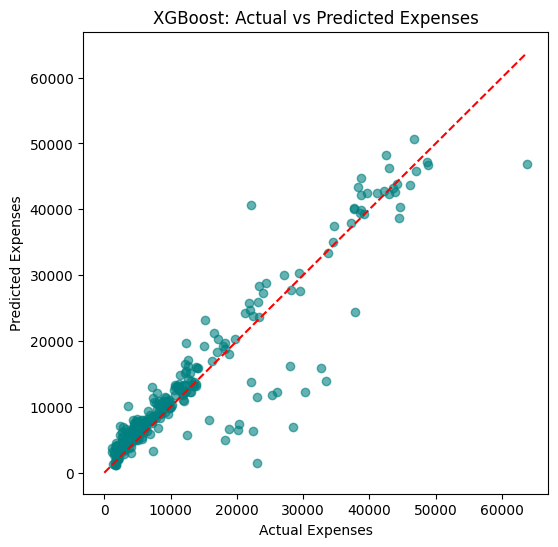

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([0, max(y_test)], [0, max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("XGBoost: Actual vs Predicted Expenses")
plt.show()


In [30]:
import joblib
joblib.dump(xgb_model, "/Users/abhishekdas/Documents/ML_FastAPI/model/xgb_insurance_model.joblib")
print("XGBoost model saved successfully.")


XGBoost model saved successfully.
